Isabella Esquivel
March 31, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146


##Heart Failure: Predictors of Ejection Fraction

###Linear Models and Regularization Methods



# 1. Introduction


#### Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators relate is essential to quantifying the risk of death following heart failure and to improve disease management.

##### Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

##### Relevant Previous Analysis Results
Four classification techniques were evaluated using a held-out test set of 299 patients. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only `ejection fraction` and `serum creatinine,` test accuracy improved to approximately 85.9%.

#### Study Objective

Previous linear regression studies have found that `serum_sodium ` and `sex` have a statistically significant relationship with `ejection_fraction`. Furthermore, previous analysis indicates that `ejection_fraction `may play a substantial role in predicting the event of death following heart failure.

The objective of this study is to evaluate and compare multiple linear modeling and regularization techniques to determine how model complexity impacts predictive performance for `ejection fraction `in heart failure patients.

Specifically, methods including `best subset selection`, `stepwise selection`, `validation-set approaches`, `cross-validation`, `ridge regression`, `lasso`, and `principal component–based methods` (PCR and PLS) are applied to identify the most effective modeling approach.

# 2. Data and Methods

 ### Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

Table 1

In [ ]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

In [ ]:
HeartFailure <- read.csv("HeartFailure.csv")

In [ ]:
head(HeartFailure)
names(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


[1] "age"                      "anaemia"                 
 [3] "creatinine_phosphokinase" "diabetes"                
 [5] "ejection_fraction"        "high_blood_pressure"     
 [7] "platelets"                "serum_creatinine"        
 [9] "serum_sodium"             "sex"                     
[11] "smoking"                  "time"                    
[13] "DEATH_EVENT"

In [ ]:
?HeartFailure

Summary of each clinical and demographic factor in the Heart Failure Dataset:

In [ ]:
summary(HeartFailure)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

## 3. Model

### Best Subset Selection Approach to `Heart Failure` data.

The objective is to predict a patient's `ejection_fraction` on the basis of various clinical factors, as this value has been heavily associated with the prediction of death for heart failure patients.

 The `is.na()` function verifies that there are no missing values. Since, no variables are missing in the data set the `na.omit` function is not used.

In [ ]:
dim(HeartFailure)
sum(is.na(HeartFailure))

[1] 299  13

[1] 0

The `regsubsets()` function (part of the `leaps` library) is utilized to perform best subset selection by identifying the best model that contains a given number of predictors, where *best* is quantified using RSS.

This analysis is performed to understand which clinical and demographic factors (such as `age`, `serum sodium`, and `creatinine levels`) are most strongly associated with `ejection fraction` in heart failure patients.

In [ ]:
install.packages('leaps')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



The best subset selection results identify the optimal combination of predictors for each model size, with variables such as serum sodium, age, and sex consistently appearing in top-performing models.

Below the `summary()` command outputs the best set of variables for each model size. An asterisk indicates that a given variable is included in the corresponding model.
For instance, this output indicates that the best two-variable model contains only `serum_sodium` and `sex`.
By default, `regsubsets()` only reports results up to the best eight-variable model.

In [ ]:
library(leaps)
regfit.full <- regsubsets(ejection_fraction ~ . - DEATH_EVENT ,HeartFailure)
summary(regfit.full)

Subset selection object
Call: regsubsets.formula(ejection_fraction ~ . - DEATH_EVENT, HeartFailure)
11 Variables  (and intercept)
                         Forced in Forced out
age                          FALSE      FALSE
anaemia                      FALSE      FALSE
creatinine_phosphokinase     FALSE      FALSE
diabetes                     FALSE      FALSE
high_blood_pressure          FALSE      FALSE
platelets                    FALSE      FALSE
serum_creatinine             FALSE      FALSE
serum_sodium                 FALSE      FALSE
sex                          FALSE      FALSE
smoking                      FALSE      FALSE
time                         FALSE      FALSE
1 subsets of each size up to 8
Selection Algorithm: exhaustive
         age anaemia creatinine_phosphokinase diabetes high_blood_pressure
1  ( 1 ) " " " "     " "                      " "      " "                
2  ( 1 ) " " " "     " "                      " "      " "                
3  ( 1 ) "*" " "     " "      

 Here the max is set to fit up to an 11-variable model, as that is the number of predictors in the dataset. This analysis reveals that variables such as `smoking`, `anaemia`, and `high_blood_pressure`, may be weak or weaker predictors of `ejection_fraction`.

In [ ]:
regfit.full <- regsubsets(ejection_fraction~ . - DEATH_EVENT, data = HeartFailure,
    nvmax = 11)
reg.summary <- summary(regfit.full)
summary(regfit.full)

Subset selection object
Call: regsubsets.formula(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure, 
    nvmax = 11)
11 Variables  (and intercept)
                         Forced in Forced out
age                          FALSE      FALSE
anaemia                      FALSE      FALSE
creatinine_phosphokinase     FALSE      FALSE
diabetes                     FALSE      FALSE
high_blood_pressure          FALSE      FALSE
platelets                    FALSE      FALSE
serum_creatinine             FALSE      FALSE
serum_sodium                 FALSE      FALSE
sex                          FALSE      FALSE
smoking                      FALSE      FALSE
time                         FALSE      FALSE
1 subsets of each size up to 11
Selection Algorithm: exhaustive
          age anaemia creatinine_phosphokinase diabetes high_blood_pressure
1  ( 1 )  " " " "     " "                      " "      " "                
2  ( 1 )  " " " "     " "                      " "      " "                
3 

The `summary()` function also returns $R^2$, RSS, adjusted $R^2$, $C_p$, and BIC. These are examined to select the *best* overall model.

In [ ]:
names(reg.summary)

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"

#### $R^2$, RSS, adjusted $R^2$, $C_p$, and BIC

For instance, we see that the $R^2$ statistic increases from $3\,\%$, when only one variable is included in the model, to $6\,\%$, when all variables are included. The R² value increases as more variables are added, which is expected since additional predictors improve model fit.

However, because R² always increases, it is not a reliable metric for selecting the optimal model.

In [ ]:
reg.summary$rsq

[1] 0.03094161 0.05156016 0.05758858 0.05982167 0.06166982 0.06300598
 [7] 0.06328736 0.06336049 0.06344462 0.06345725 0.06345819

 RSS, adjusted $R^2$, $C_p$, and BIC is plotted for all of the models at once to determine which model to select.

The RSS decreases as more variables are added, indicating improved model fit. However, after around 5-6 variables this trend slows down. So, adding more complexity may not be worth the same gain.

On the other hand, the adjusted R² peaks at approximately 3–4 variables and then declines, possibly meaning that models beyond this size add unnecessary complexity without improving predictive performance.

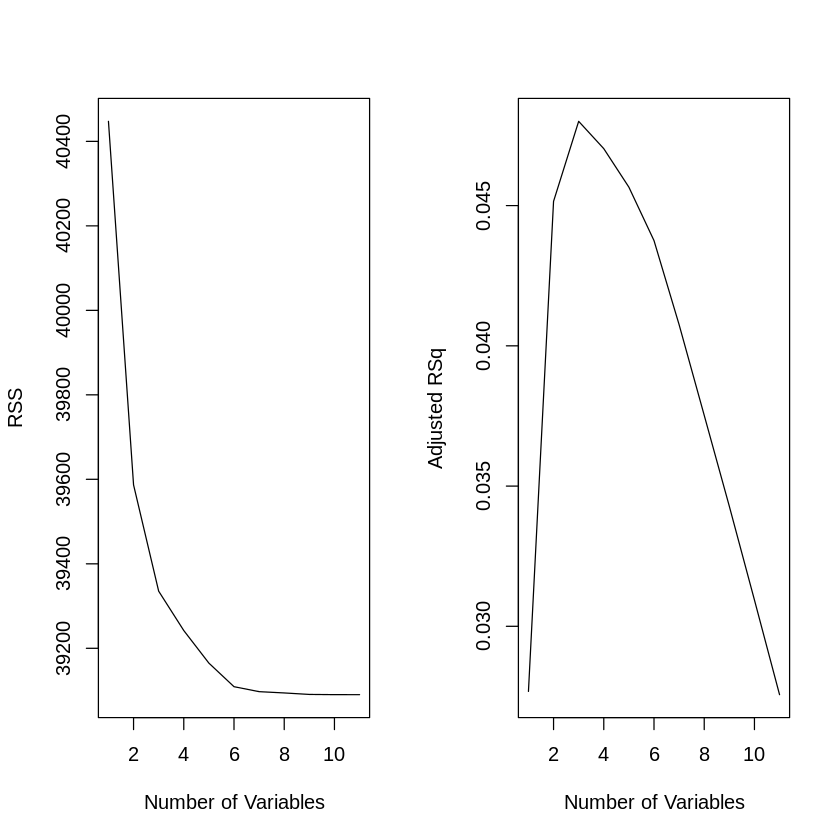

In [ ]:
par(mfrow = c(1, 2))
plot(reg.summary$rss, xlab = "Number of Variables",
    ylab = "RSS", type = "l")
plot(reg.summary$adjr2, xlab = "Number of Variables",
    ylab = "Adjusted RSq", type = "l")

The `which.max()` function is utilized to identify the model with the largest adjusted $R^2$ statistic. The adjusted R² is maximized at 3 variables, indicating that the optimal model potentially includes only three predictors.

[1] 3

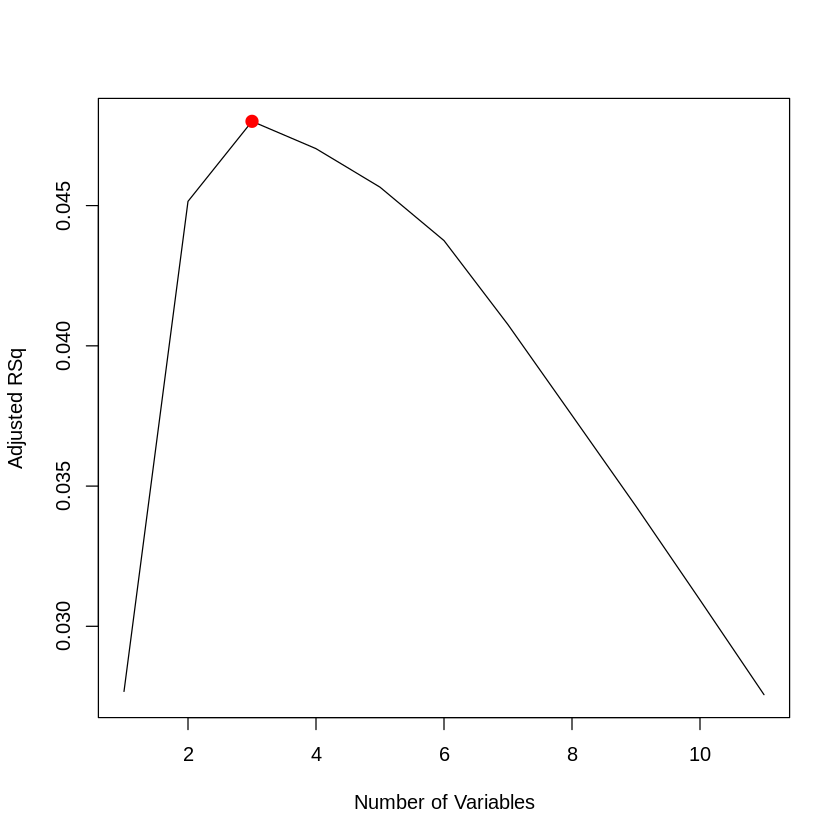

In [ ]:
which.max(reg.summary$adjr2)
plot(reg.summary$adjr2, xlab = "Number of Variables",
    ylab = "Adjusted RSq", type = "l")
points(3, reg.summary$adjr2[3], col = "red", cex = 2,
    pch = 20)

In a similar fashion, the $C_p$ and BIC statistics are plotted, and `which.min()` is used to indicate the models with the smallest statistic. While adjusted R² is maximized at three variables, both Cp and BIC identify the optimal model at two variables.

[1] 2

[1] 2

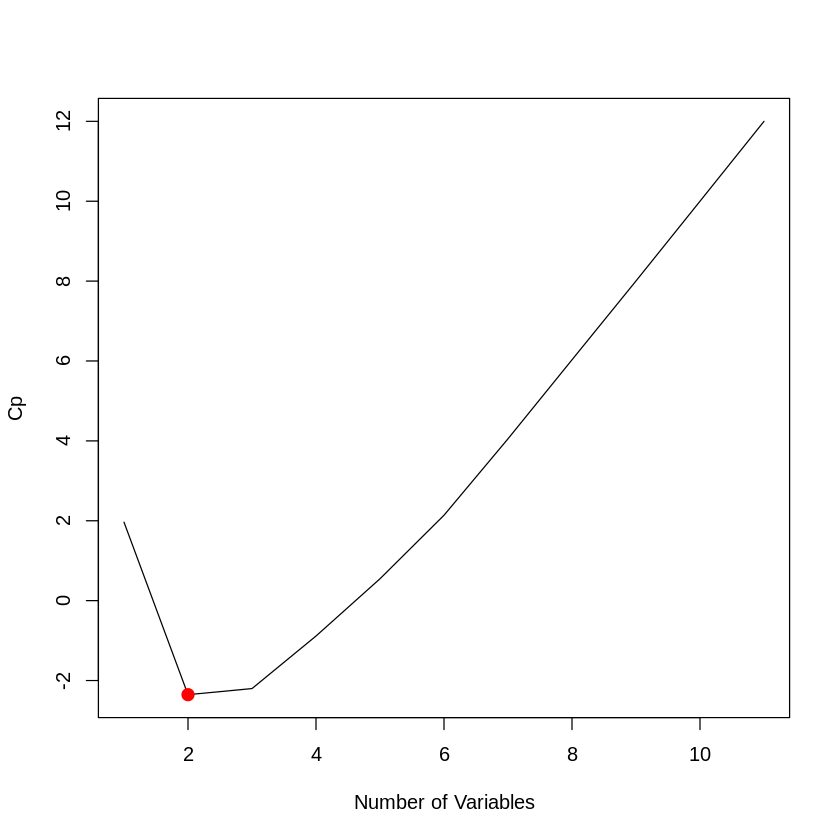

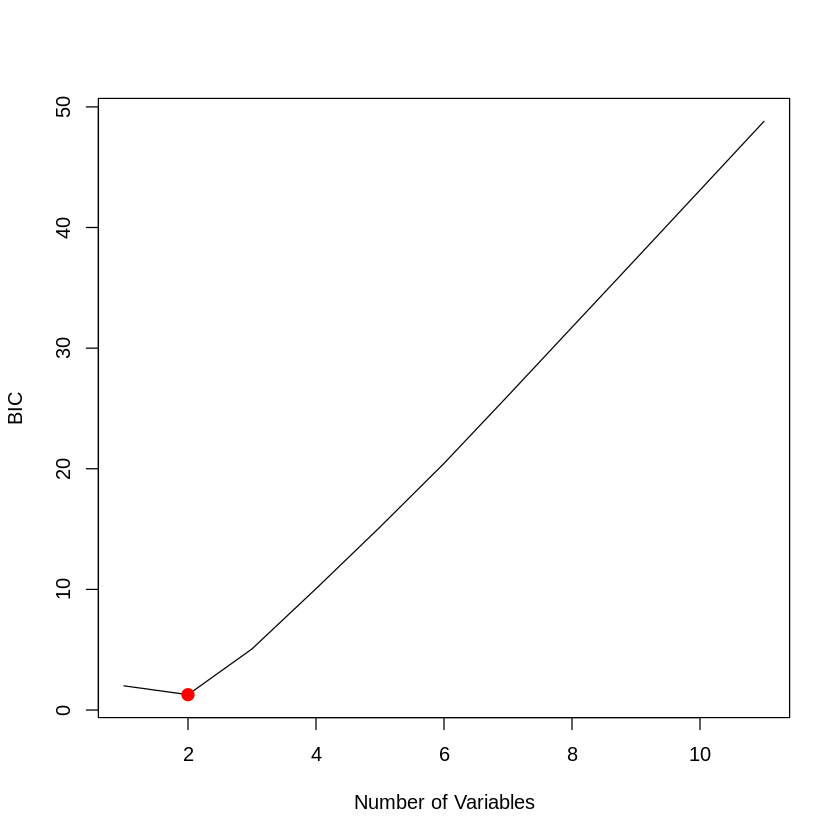

In [ ]:
plot(reg.summary$cp, xlab = "Number of Variables",
    ylab = "Cp", type = "l")
which.min(reg.summary$cp)
points(2, reg.summary$cp[2], col = "red", cex = 2,
    pch = 20)
which.min(reg.summary$bic)
plot(reg.summary$bic, xlab = "Number of Variables",
    ylab = "BIC", type = "l")
points(2, reg.summary$bic[2], col = "red", cex = 2,
    pch = 20)

Now that the optimal number of predictors has been analyzed, the next step is determine which predictors.

The `regsubsets()` function has a built-in `plot()` command which can be used to display the selected variables for the best model with a given number of predictors, ranked according to the BIC, $C_p$, adjusted $R^2$, or AIC.

##### R²: Selected Predictors

Once again, the R² plot favors larger models since R² always increases as more variables are added, whereas the adjusted R² plot selects a smaller model because it penalizes unnecessary predictors.

In [ ]:
which.min(reg.summary$adjr2)
coef(regfit.full, 11)

[1] 11

(Intercept)                      age                  anaemia 
           -3.061804e+01             8.266822e-02             8.795753e-02 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -4.485011e-04            -2.312230e-01            -2.482491e-02 
               platelets         serum_creatinine             serum_sodium 
            6.201799e-06             1.885314e-01             4.645886e-01 
                     sex                  smoking                     time 
           -3.363936e+00            -2.545437e-01             6.868277e-03

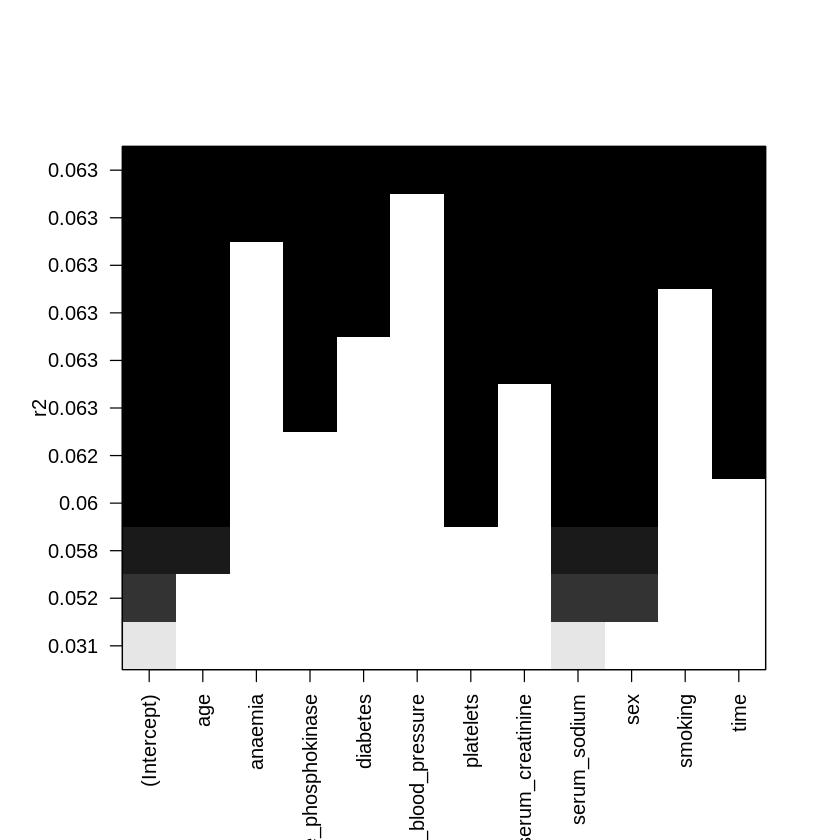

In [ ]:
plot(regfit.full, scale = "r2")

##### Adjusted R²: Selected Predictors

Based on the adjusted R² criterion, the optimal model includes only three variables as indicated earlier with the `which.max`. This plot reveals that those three predictors are:

1.   `age`
2.  `sex`
3. `serum_sodium`.


In [ ]:
which.max(reg.summary$adjr2)
coef(regfit.full, 3)

[1] 3

(Intercept)          age serum_sodium          sex 
-28.51261070   0.07749333   0.47040481  -3.67932157

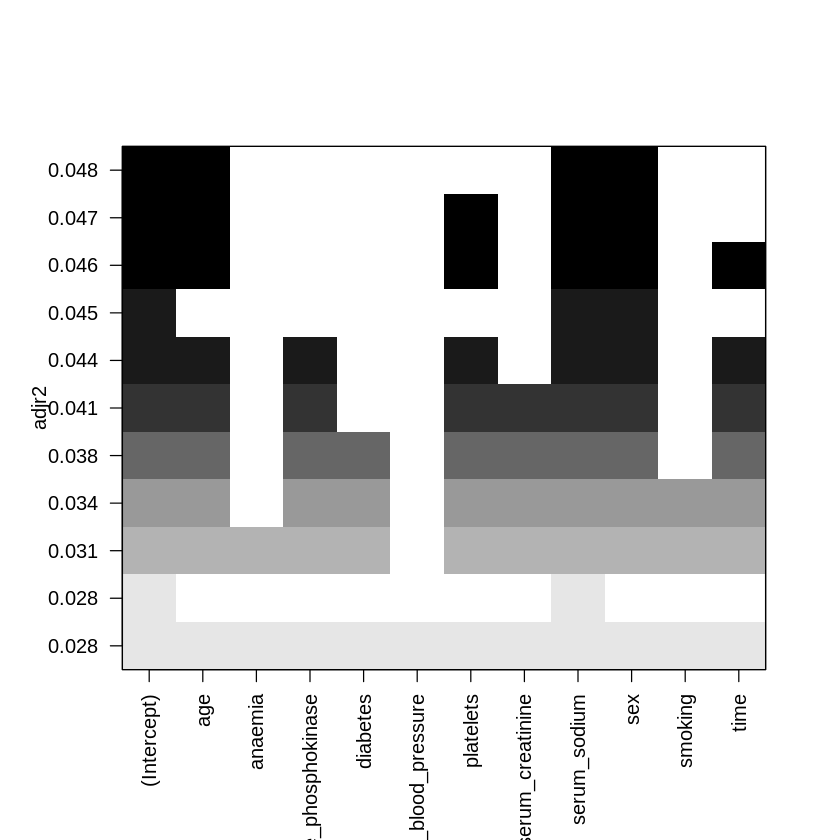

In [ ]:
plot(regfit.full, scale = "adjr2")

##### Cp: Selected Predictors

Based on the Cp criterion, the optimal model includes only two variables as indicated earlier with the `which.min`function. This plot reveals that those are two predictors are:

1.  `sex`
2. `serum_sodium`

Therefore, age is not included for this best model analysis unlike adjusted R².


In [ ]:
which.min(reg.summary$cp)
coef(regfit.full, 2)

[1] 2

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

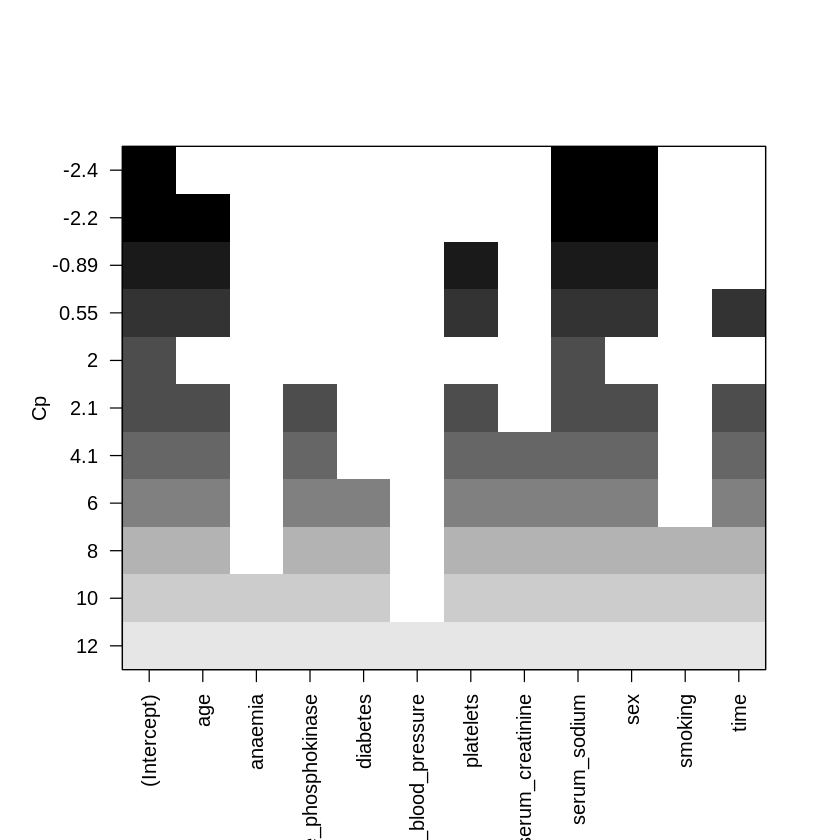

In [ ]:
plot(regfit.full, scale = "Cp")

##### BIC: Selected Predictors

Based on the BIC criterion, the optimal model includes only two variables as indicated earlier with the `which.min`function. This plot reveals that those  two predictors are:

1.  `sex`
2. `serum_sodium`

Therefore, `age` is not included in for this best model analysis unlike adjusted R², but similar to Cp.

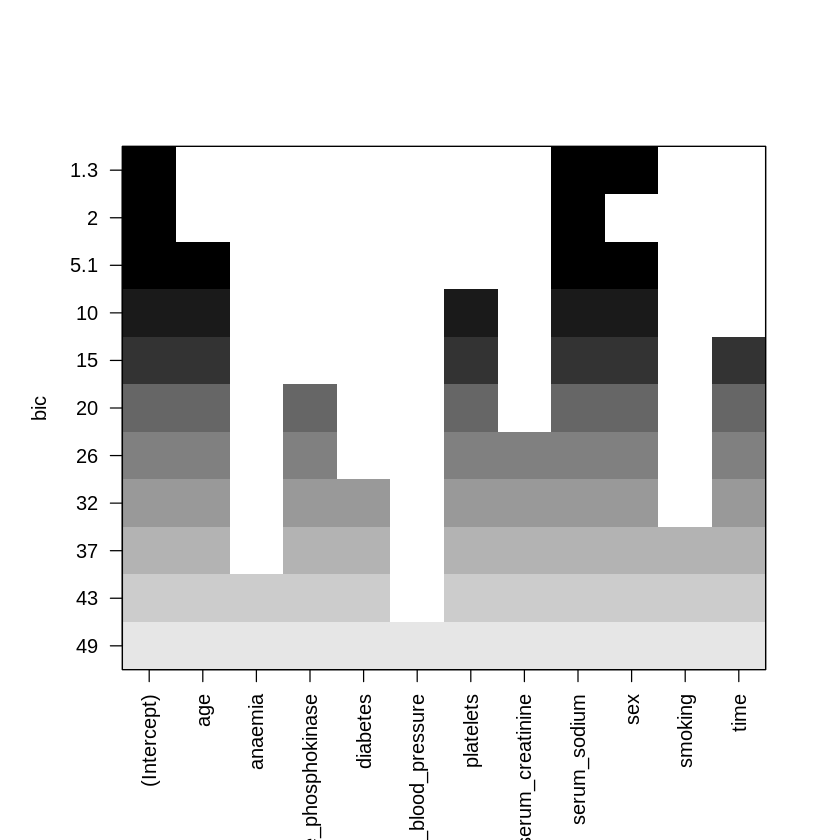

In [ ]:
plot(regfit.full, scale = "bic")

In [ ]:
which.min(reg.summary$bic)
coef(regfit.full, 2)

[1] 2

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

### Forward and Backward Stepwise Selection


Since the dataset includes many potential predictors, forward and backward selection were used to determine which variables actually contribute to explaining `ejection fraction`, rather than relying on assumptions.

##### Forward Stepwise Selection

Unlike the exhaustive approach used previously, forward selection builds the model sequentially by adding predictors that provide the greatest improvement at each step.

However, there does seem to be consistency as the weakest predictors remain:



1.  ` high blood pressure`
2.  `smoking`
3. `anaemia`

With the strongest predictors remaining as:

1. `serum sodium`
2. `sex`
3. `age`




In [ ]:
regfit.fwd <- regsubsets(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure,
    nvmax = 11, method = "forward")
summary(regfit.fwd)

Subset selection object
Call: regsubsets.formula(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure, 
    nvmax = 11, method = "forward")
11 Variables  (and intercept)
                         Forced in Forced out
age                          FALSE      FALSE
anaemia                      FALSE      FALSE
creatinine_phosphokinase     FALSE      FALSE
diabetes                     FALSE      FALSE
high_blood_pressure          FALSE      FALSE
platelets                    FALSE      FALSE
serum_creatinine             FALSE      FALSE
serum_sodium                 FALSE      FALSE
sex                          FALSE      FALSE
smoking                      FALSE      FALSE
time                         FALSE      FALSE
1 subsets of each size up to 11
Selection Algorithm: forward
          age anaemia creatinine_phosphokinase diabetes high_blood_pressure
1  ( 1 )  " " " "     " "                      " "      " "                
2  ( 1 )  " " " "     " "                      " "      " "  

##### Backward Stepwise Selection

The backward stepwise selection further proved this by having very consistent results as well:

In [ ]:
regfit.bwd <- regsubsets(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure,
    nvmax = 11,, method = "backward")
summary(regfit.bwd)

Subset selection object
Call: regsubsets.formula(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure, 
    nvmax = 11, , method = "backward")
11 Variables  (and intercept)
                         Forced in Forced out
age                          FALSE      FALSE
anaemia                      FALSE      FALSE
creatinine_phosphokinase     FALSE      FALSE
diabetes                     FALSE      FALSE
high_blood_pressure          FALSE      FALSE
platelets                    FALSE      FALSE
serum_creatinine             FALSE      FALSE
serum_sodium                 FALSE      FALSE
sex                          FALSE      FALSE
smoking                      FALSE      FALSE
time                         FALSE      FALSE
1 subsets of each size up to 11
Selection Algorithm: backward
          age anaemia creatinine_phosphokinase diabetes high_blood_pressure
1  ( 1 )  " " " "     " "                      " "      " "                
2  ( 1 )  " " " "     " "                      " "      "

#### Similarity

For this data, the best one-variable through eleven-variable models are each almost identical. For example, here is the comparison with 2 and 3 predictors.

In [ ]:
coef(regfit.full, 2)
coef(regfit.fwd, 2)
coef(regfit.bwd, 2)

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

In [ ]:
coef(regfit.full, 3)
coef(regfit.fwd, 3)
coef(regfit.bwd, 3)

(Intercept)          age serum_sodium          sex 
-28.51261070   0.07749333   0.47040481  -3.67932157

(Intercept)          age serum_sodium          sex 
-28.51261070   0.07749333   0.47040481  -3.67932157

(Intercept)          age serum_sodium          sex 
-28.51261070   0.07749333   0.47040481  -3.67932157

Furthermore, the Cp plots for forward and backward selection are nearly identical, indicating that both approaches consistently identify the same set of important predictors and yield very similar model selections.

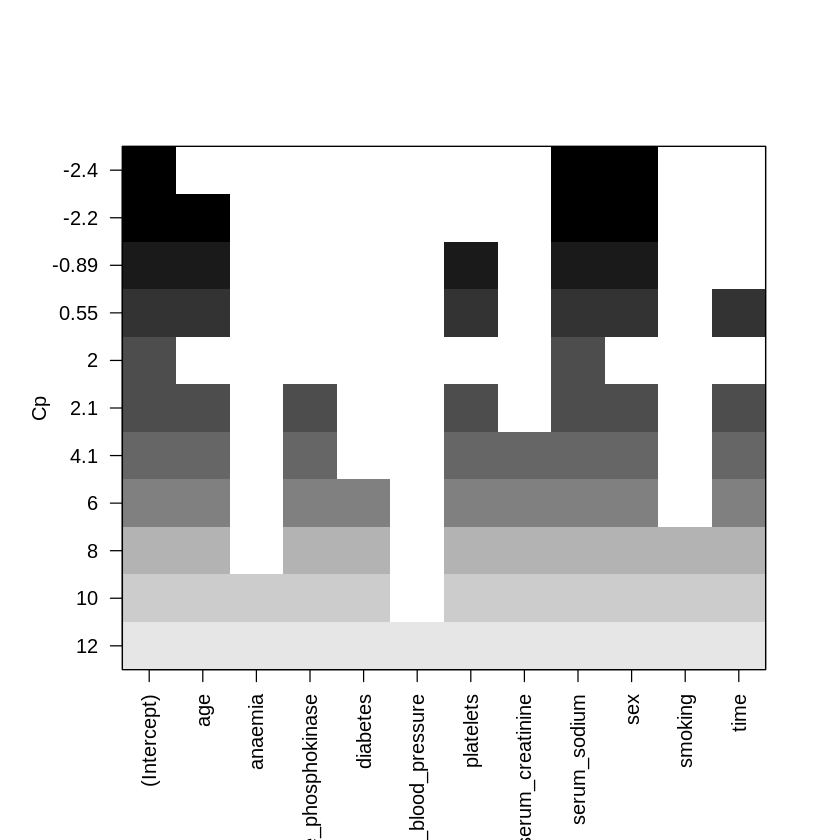

In [ ]:
plot(regfit.fwd, scale = "Cp")

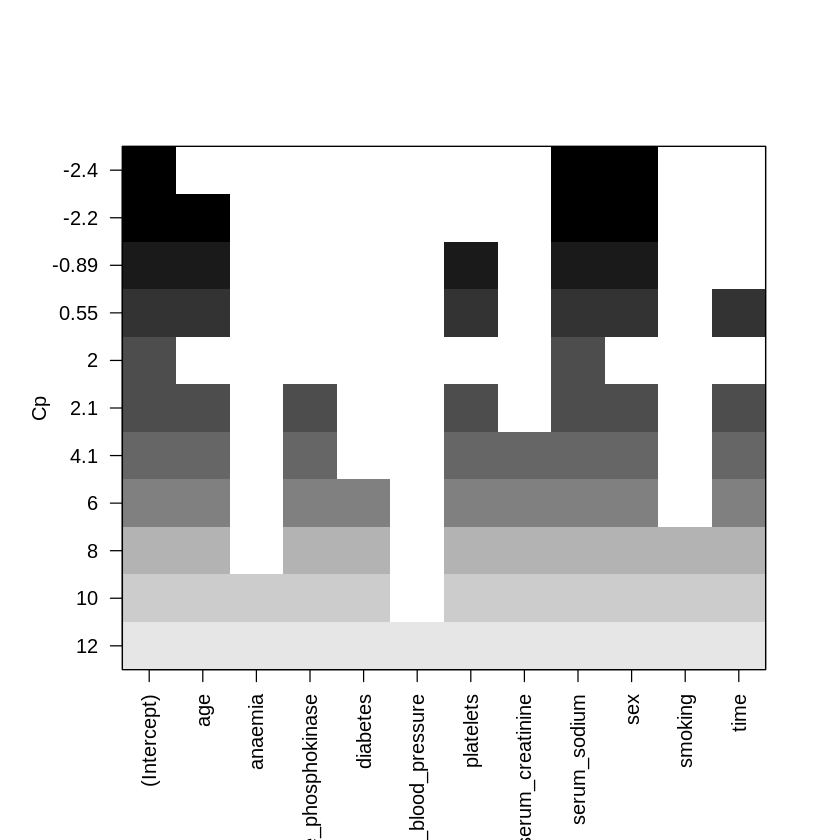

In [ ]:
plot(regfit.bwd, scale = "Cp")

### Choosing Among Models Using the Validation-Set Approach and Cross-Validation

#### Validation-Set Approach

To evaluate model performance more realistically, the `Heart Failure` dataset was split into training and test sets rather than using the full dataset for both model selection and evaluation. This is important because selecting predictors of ejection fraction using the entire dataset can lead to overly optimistic results and does not accurately reflect how the model would perform on new patients.

In [ ]:
set.seed(1)
train <- sample(c(TRUE, FALSE), nrow(HeartFailure),
    replace = TRUE)
test <- (!train)

Best subset selection was applied to the training data to identify the most relevant clinical predictors of `ejection fraction`, ensuring that variable selection was not influenced by the test set.

In [ ]:
regfit.best <- regsubsets(ejection_fraction ~ . - DEATH_EVENT,
data = HeartFailure[train, ], nvmax = 11)

Now a loop is run for each size `i` to extract the coefficients from
`regfit.best` for the best model of that size, multiply them into
the appropriate columns of the test model matrix to form the
predictions, and compute the test MSE.

In [ ]:
test.mat <- model.matrix(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure[test, ])

In [ ]:
val.errors <- rep(NA, 11)
for (i in 1:11) {
 coefi <- coef(regfit.best, id = i)
 pred <- test.mat[, names(coefi)] %*% coefi
 val.errors[i] <- mean((HeartFailure$ejection_fraction[test] - pred)^2)
}

The model with three predictors produced the lowest test MSE, indicating that this model provides the best balance between accuracy and complexity for predicting `ejection fraction` in new patients. Since model selection is based on miniming test MSE, two different predictors were included in the best fit model.

**Different**

1.   Anaemia vs Age from previous
2.   Creatinine Phosphokinase vs Sex from previous


**No Change**


1.   Serum Sodium

In fact, anaemia was one of the weaker indicators when conducting the previous subset selection on the full dataset.


In [ ]:
val.errors
which.min(val.errors)
coef(regfit.best, 3)

[1] 165.9661 167.7654 160.2999 164.5163 163.6348 162.8618 162.4080 161.3876
 [9] 161.4812 161.4909 161.5002

[1] 3

(Intercept)                  anaemia creatinine_phosphokinase 
            -0.091244025             -2.238396312             -0.001291916 
            serum_sodium 
             0.282097392

Custom function to generate predictions by multiplying the selected predictors by their corresponding coefficients:


In [ ]:
 predict.regsubsets <- function(object, newdata, id, ...) {
  form <- as.formula(object$call[[2]])
  mat <- model.matrix(form, newdata)
  coefi <- coef(object, id = id)
  xvars <- names(coefi)
  mat[, xvars] %*% coefi
 }

Finally, best subset selection is performed on the full data set to select the best three-variable model. The full data set is used to obtain more accurate coefficient estimates. The best three-variable model on the full data set may differ from the corresponding model on the training set, so we cannot simply use the variables found from its analysis.

In [ ]:
regfit.best <- regsubsets(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure,
    nvmax = 11)
coef(regfit.best, 3)

(Intercept)          age serum_sodium          sex 
-28.51261070   0.07749333   0.47040481  -3.67932157

While using the training set demonstrated that a three-variable model is best, the best clinical factors on the full dataset were once again `sex`, `age`, and `serum sodium`.

#### Cross- Validation

A 10-fold cross-validation approach was used to compare models of different sizes. The `Heart Failure` dataset was randomly partitioned into ten folds, and best subset selection was performed within each training set. Prediction errors were recorded and stored to evaluate model performance across folds.

In [ ]:
k <- 10
n <- nrow(HeartFailure)
set.seed(1)
folds <- sample(rep(1:k, length = n))
cv.errors <- matrix(NA, k, 11,
    dimnames = list(NULL, paste(1:11)))

A for loop was used to carry out 10-fold cross-validation, where each fold served as the validation set once.

In [ ]:
for (j in 1:k) {
  best.fit <- regsubsets(ejection_fraction ~ . - DEATH_EVENT,
       data = HeartFailure[folds != j, ],
       nvmax = 11)
  for (i in 1:11) {
    pred <- predict(best.fit, HeartFailure[folds == j, ], id = i)
    cv.errors[j, i] <-
         mean((HeartFailure$ejection_fraction[folds == j] - pred)^2)
   }
 }

This creates a $10 \times 11$ matrix, of which the $(j,i)$th element  corresponds to the test MSE for the $j$th
cross-validation fold for the best $i$-variable model. The errors are then averaged across folds for each model size, providing a single cross-validation error for each number of predictors. The model with the lowest average error is selected as the optimal model.

1        2        3        4        5        6        7        8 
137.3438 134.5317 135.2930 138.5614 139.4436 139.9569 140.9130 141.3049 
       9       10       11 
142.1352 142.1965 142.2861

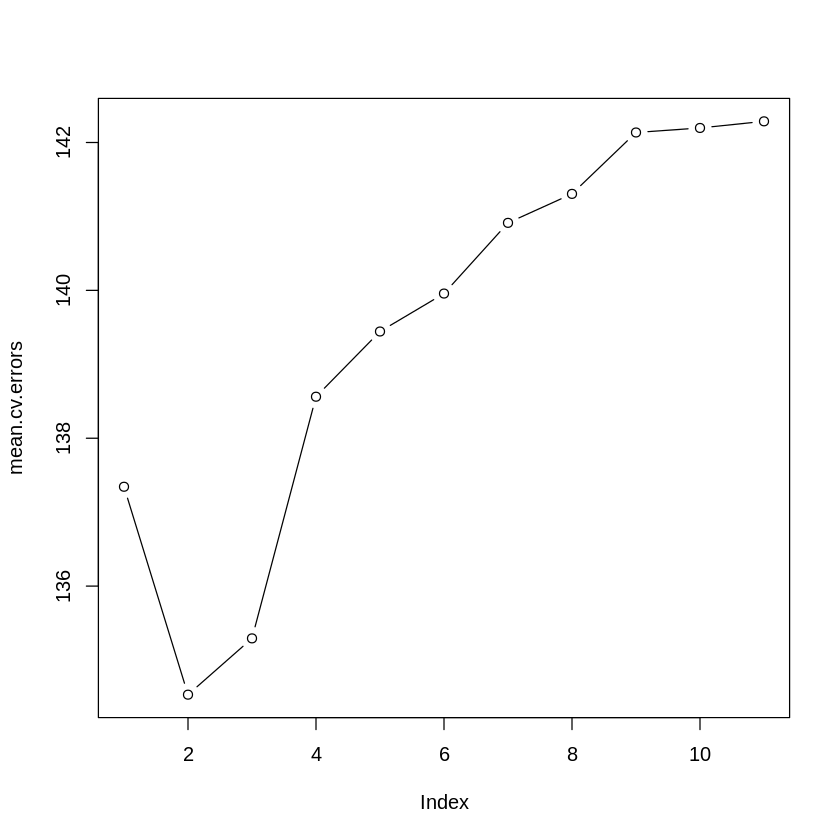

In [ ]:
mean.cv.errors <- apply(cv.errors, 2, mean)
mean.cv.errors
par(mfrow = c(1, 1))
plot(mean.cv.errors, type = "b")

Cross-validation selects a two-variable model. Beyond two variables, the error increases, meaning that adding more predictors may lead to overfitting rather than improved performance.

 Next, best subset selection is performed on the full data set in order to obtain the 2-variable model.

**The two selected variables are:**



1.   Serum Sodium
2. Sex



In [ ]:
reg.best <- regsubsets(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure,
    nvmax = 11)
coef(reg.best, 2)

(Intercept) serum_sodium          sex 
 -22.6173109    0.4611723   -3.5555329

### Ridge Regression and the Lasso

While best subset selection identified a two-variable model, this approach can be unstable and sensitive to small changes in the data. To address this limitation, we apply ridge and lasso regression, which introduces regularization to control model complexity.

Here the predictor matrix was constructed using the `model.matrix()` function, which creates a matrix corresponding to the 11 predictors:


In [ ]:
x <- model.matrix(ejection_fraction ~ . - DEATH_EVENT, HeartFailure)[, -1]
y <- HeartFailure$ejection_fraction



#### Ridge Regression

First, a ridge regression model is fit by setting `alpha=0`:

In [ ]:
install.packages('glmnet')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’




In [ ]:
library(glmnet)
grid <- 10^seq(10, -2, length = 100)
ridge.mod <- glmnet(x, y, alpha = 0, lambda = grid)

Loading required package: Matrix

Loaded glmnet 4.1-10



 Rather than selecting a single subset of predictors, ridge regression estimates models across a range of penalty values (λ), which control the degree of coefficient shrinkage. However, here the function is implemented over a grid of values ranging from $\lambda=10^{10}$ to $\lambda=10^{-2}$, essentially covering the full range of scenarios from the null model containing only the intercept, to the least squares fit.

Associated with each value of $\lambda$ is a vector of ridge regression coefficients, stored in a matrix that can be accessed by `coef()`. In this case, it is a $12 \times 100$
matrix, with $12$ rows (one for each predictor, plus an intercept) and $100$ columns (one for each value of $\lambda$).

In [ ]:
dim(coef(ridge.mod))

[1]  12 100

The following results illustrate the effect of the ridge penalty on coefficient estimates. As the value of λ increases, the magnitude of the coefficients decreases, as reflected in a smaller ℓ₂ norm.

 These are the coefficients when $\lambda=11{,}498$, along with their $\ell_2$ norm:

In [ ]:
ridge.mod$lambda[50]
coef(ridge.mod)[, 50]
sqrt(sum(coef(ridge.mod)[-1, 50]^2))

[1] 11497.57

(Intercept)                      age                  anaemia 
            3.801351e+01             6.140303e-05             7.721231e-04 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -5.517709e-07            -1.196099e-04             6.204446e-04 
               platelets         serum_creatinine             serum_sodium 
            8.963671e-09            -1.324911e-04             4.842952e-04 
                     sex                  smoking                     time 
           -3.769308e-03            -1.746918e-03             6.532098e-06

[1] 0.004302411

In contrast, here are the coefficients when $\lambda=705$, along with their $\ell_2$ norm. Note the much larger $\ell_2$ norm of the coefficients associated with this smaller value of $\lambda$.

In [ ]:
ridge.mod$lambda[60]
coef(ridge.mod)[, 60]
sqrt(sum(coef(ridge.mod)[-1, 60]^2))

[1] 705.4802

(Intercept)                      age                  anaemia 
            3.695936e+01             9.916068e-04             1.218302e-02 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -8.814869e-06            -2.040053e-03             9.757543e-03 
               platelets         serum_creatinine             serum_sodium 
            1.430890e-07            -2.038118e-03             7.763078e-03 
                     sex                  smoking                     time 
           -6.017390e-02            -2.760239e-02             1.048430e-04

[1] 0.06852738

**0.0043 vs 0.0685**

The larger the λ, the stronger the shrinkage, and the simpler the model.

The ridge regression coefficients for a new value of $\lambda$, $50$, is obtained using the predict `function`:

In [ ]:
predict(ridge.mod, s = 50, type = "coefficients")[1:12, ]

(Intercept)                      age                  anaemia 
            2.493180e+01             1.247576e-02             1.169407e-01 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -9.900515e-05            -3.691429e-02             8.947826e-02 
               platelets         serum_creatinine             serum_sodium 
            1.588916e-06            -1.251613e-02             9.035484e-02 
                     sex                  smoking                     time 
           -6.727564e-01            -2.701314e-01             1.239719e-03

Here the samples are split into a training set and a test set in order to estimate the test error of ridge regression and the lasso.

First a random seed is set, so that the results obtained will be reproducible.

In [ ]:
set.seed(1)
train <- sample(1:nrow(x), nrow(x) / 2)
test <- (-train)
y.test <- y[test]

A ridge regression model with λ = 4 produced a test MSE of 139.34. This performance is slightly worse than a baseline model that predicts the mean of the training response, which achieved a test MSE of 138.61.

In [ ]:
ridge.mod <- glmnet(x[train, ], y[train], alpha = 0,
    lambda = grid, thresh = 1e-12)
ridge.pred <- predict(ridge.mod, s = 4, newx = x[test, ])
mean((ridge.pred - y.test)^2)

[1] 139.3399

In [ ]:
mean((mean(y[train]) - y.test)^2)

[1] 138.6092

Additionally, when λ is set to a very large value, the ridge model yields the same MSE as the mean model, since all coefficients are shrunk toward zero and the model effectively reduces to predicting the intercept. Note that `1e10` means $10^{10}$.

In [ ]:
ridge.pred <- predict(ridge.mod, s = 1e10, newx = x[test, ])
mean((ridge.pred - y.test)^2)

[1] 138.6092

To verify the relationship between ridge regression and ordinary least squares, we evaluated the ridge model at λ = 0. At this value, the penalty term is eliminated, and the ridge model reduces to standard least squares regression.

The resulting coefficient estimates closely match those obtained from the linear regression model, confirming their equivalence. The test MSE of approximately 144.53 reflects the predictive performance of the unregularized model. This indicates that regularization improves predictive performance by reducing overfitting, since the earlier results with λ = 4 achieved lower test mean squared error.

In [ ]:
ridge.pred <- predict(ridge.mod, s = 0, newx = x[test, ],
    exact = T, x = x[train, ], y = y[train])
mean((ridge.pred - y.test)^2)
lm(y ~ x, subset = train)
predict(ridge.mod, s = 0, exact = T, type = "coefficients",
    x = x[train, ], y = y[train])[1:12, ]

[1] 144.5313


Call:
lm(formula = y ~ x, subset = train)

Coefficients:
              (Intercept)                       xage  
                1.565e+01                 -1.517e-04  
                 xanaemia  xcreatinine_phosphokinase  
               -2.974e-01                 -1.022e-03  
                xdiabetes       xhigh_blood_pressure  
               -2.542e+00                 -1.109e+00  
               xplatelets          xserum_creatinine  
                1.088e-05                  6.732e-01  
            xserum_sodium                       xsex  
                1.830e-01                 -4.779e+00  
                 xsmoking                      xtime  
                1.534e+00                 -1.151e-02  


(Intercept)                      age                  anaemia 
            1.565424e+01            -1.517316e-04            -2.974355e-01 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -1.022151e-03            -2.542269e+00            -1.108510e+00 
               platelets         serum_creatinine             serum_sodium 
            1.088495e-05             6.732040e-01             1.829956e-01 
                     sex                  smoking                     time 
           -4.778652e+00             1.534479e+00            -1.151305e-02

Cross-validation selects a large value of λ (approximately 2077) as minimizing the validation error, the test MSE is 138.55, slightly better than the baseline.

[1] 2077.303

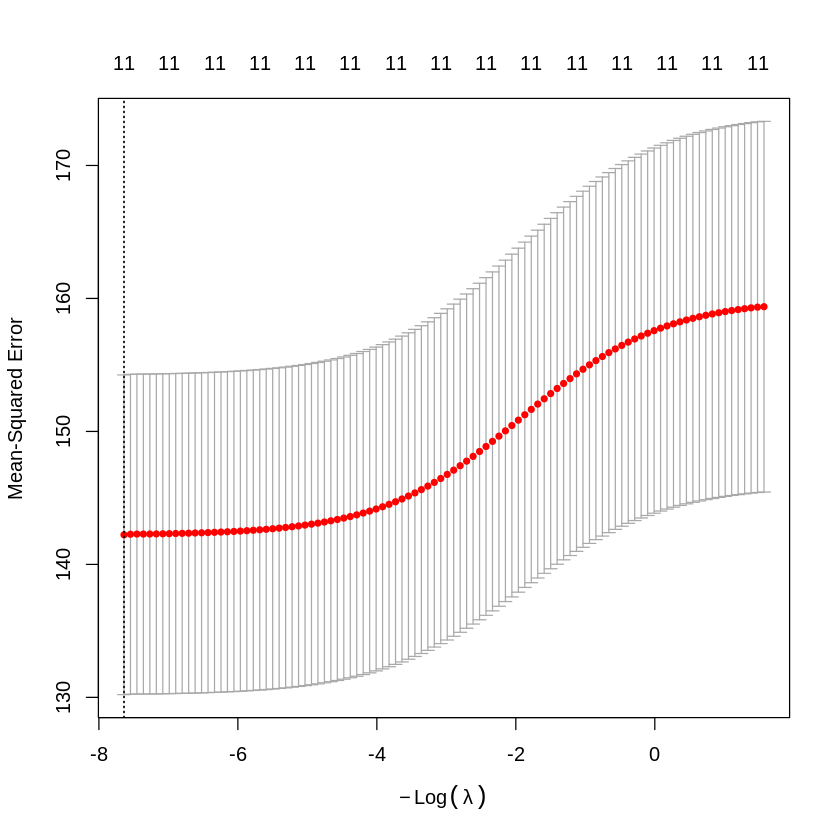

In [ ]:
set.seed(1)
cv.out <- cv.glmnet(x[train, ], y[train], alpha = 0)
plot(cv.out)
bestlam <- cv.out$lambda.min
bestlam

In [ ]:
ridge.pred <- predict(ridge.mod, s = bestlam,
    newx = x[test, ])
mean((ridge.pred - y.test)^2)

[1] 138.5523

Additionally, the cross-validation error curve is relatively flat across a range of λ values, indicating that multiple levels of regularization yield similar performance.

The ridge regression model is refit on the full data set, using the value of $\lambda$ chosen by cross-validation, and then the coefficient estimates are examined:

In [ ]:
out <- glmnet(x, y, alpha = 0)
predict(out, type = "coefficients", s = bestlam)[1:12, ]

(Intercept)                      age                  anaemia 
            3.808135e+01             1.989248e-06             2.481503e-05 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
           -1.780925e-08            -3.952179e-06             1.991857e-05 
               platelets         serum_creatinine             serum_sodium 
            2.892252e-10            -4.220915e-06             1.564914e-05 
                     sex                  smoking                     time 
           -1.216270e-04            -5.617772e-05             2.111660e-07

While ridge regression does not set coefficients exactly to zero, the large value of λ selected here shrinks all coefficients to values extremely close to zero, effectively removing their influence on the model.

#### The Lasso

Lasso produces a sparse model by shrinking some coefficients exactly to zero, effectively selecting a subset of predictors.

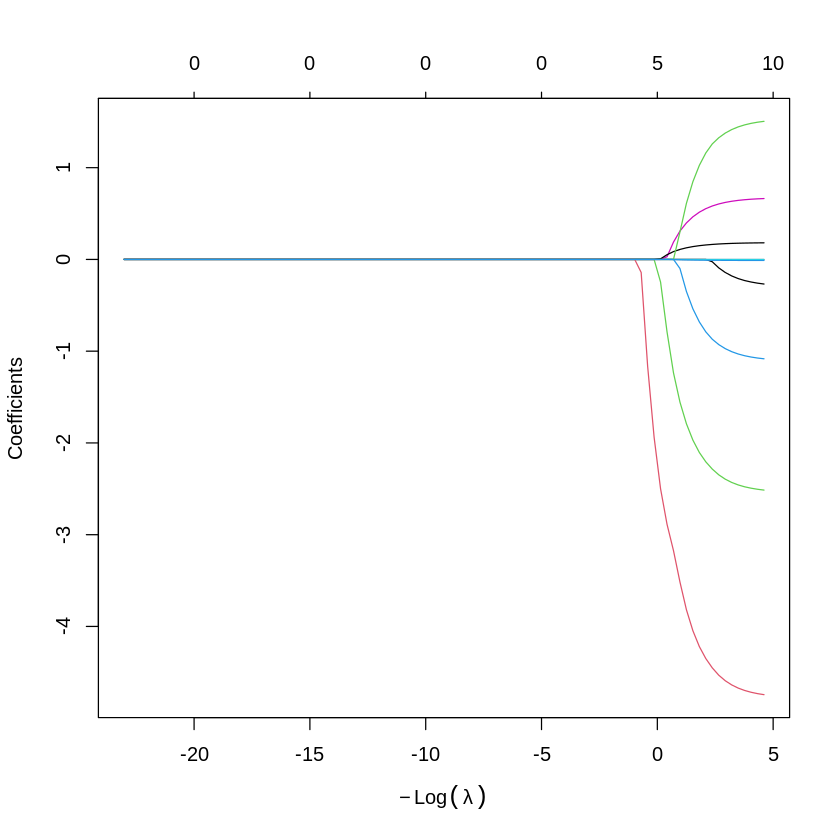

In [ ]:
lasso.mod <- glmnet(x[train, ], y[train], alpha = 1,
    lambda = grid)
plot(lasso.mod)

As λ decreases, more variables enter the model, but only the most important predictors are retained for larger values of λ.

Next, cross-validation is performed and the associated test error is computed:

[1] 137.185

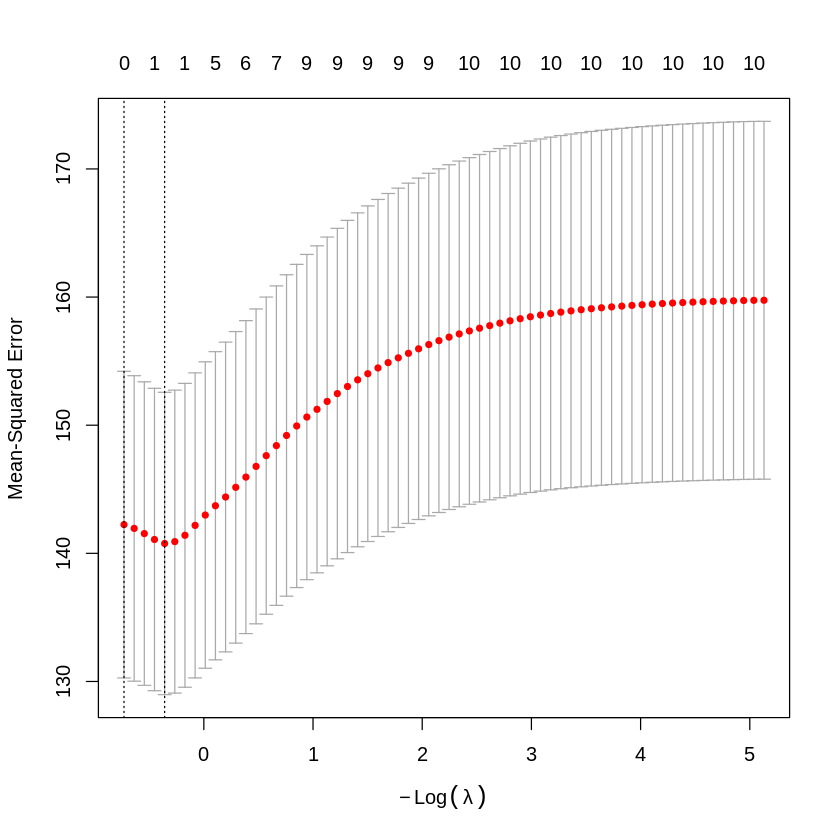

In [ ]:
set.seed(1)
cv.out <- cv.glmnet(x[train, ], y[train], alpha = 1)
plot(cv.out)
bestlam <- cv.out$lambda.min
lasso.pred <- predict(lasso.mod, s = bestlam,
    newx = x[test, ])
mean((lasso.pred - y.test)^2)

The test MSE is 137.18, which is very close to the ridge values between 136-138, but notably better than the OLS value of 144.5.

However, the lasso has a substantial advantage over ridge regression in that the resulting coefficient estimates are sparse. Here we see that 9 of the 11 coefficient estimates are exactly
zero. So the lasso model with $\lambda$ chosen by cross-validation contains only two variables: `serum_sodium `and `sex`.

In [ ]:
out <- glmnet(x, y, alpha = 1, lambda = grid)
lasso.coef <- predict(out, type = "coefficients",
    s = bestlam)[1:12, ]
lasso.coef
lasso.coef[lasso.coef != 0]

(Intercept)                      age                  anaemia 
              18.7052817                0.0000000                0.0000000 
creatinine_phosphokinase                 diabetes      high_blood_pressure 
               0.0000000                0.0000000                0.0000000 
               platelets         serum_creatinine             serum_sodium 
               0.0000000                0.0000000                0.1448578 
                     sex                  smoking                     time 
              -0.6364278                0.0000000                0.0000000

(Intercept) serum_sodium          sex 
  18.7052817    0.1448578   -0.6364278

## PCR and PLS Regression

### Principal Components Regression

Principal Components Regression was applied using standardized predictors and cross-validation in order to predict `ejection fraction` for heart failure patients.

In [ ]:
install.packages('pls')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(pls)
set.seed(2)
pcr.fit <- pcr(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure, scale = TRUE,
    validation = "CV")


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings




We standardize the predictors and use cross-validation to ensure that no variable disproportionately influences the principal components and to identify the number of components that yields the best predictive performance.

Therefore, it appears that around 3 components provides the best predictive performance according to PCR as 11.77(adjvCv = 11.75) is the smallest.

In [ ]:
summary(pcr.fit)

Data: 	X dimension: 299 11 
	Y dimension: 299 1
Fit method: svdpc
Number of components considered: 11

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           11.85    11.86    11.85    11.77    11.82    11.85    11.82
adjCV        11.85    11.83    11.84    11.75    11.81    11.84    11.80
       7 comps  8 comps  9 comps  10 comps  11 comps
CV       11.83    11.85    11.88     11.92     11.96
adjCV    11.82    11.83    11.86     11.90     11.93

TRAINING: % variance explained
                   1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
X                   14.731   29.065   39.894    50.04   59.258   67.548
ejection_fraction    1.465    1.627    3.471     3.48    3.601    4.613
                   7 comps  8 comps  9 comps  10 comps  11 comps
X                   75.477    82.81   89.433    95.322   100.000
ejection_fraction    4.902     5.64    5.954     6.063     6.346


Note that  `pcr()` reports the *root mean squared error*; in order to obtain the usual MSE, we must square this quantity. ($11.77^2$=$138.5$).

Here is the plot of the cross-validation scores using the
`validationplot()` function:

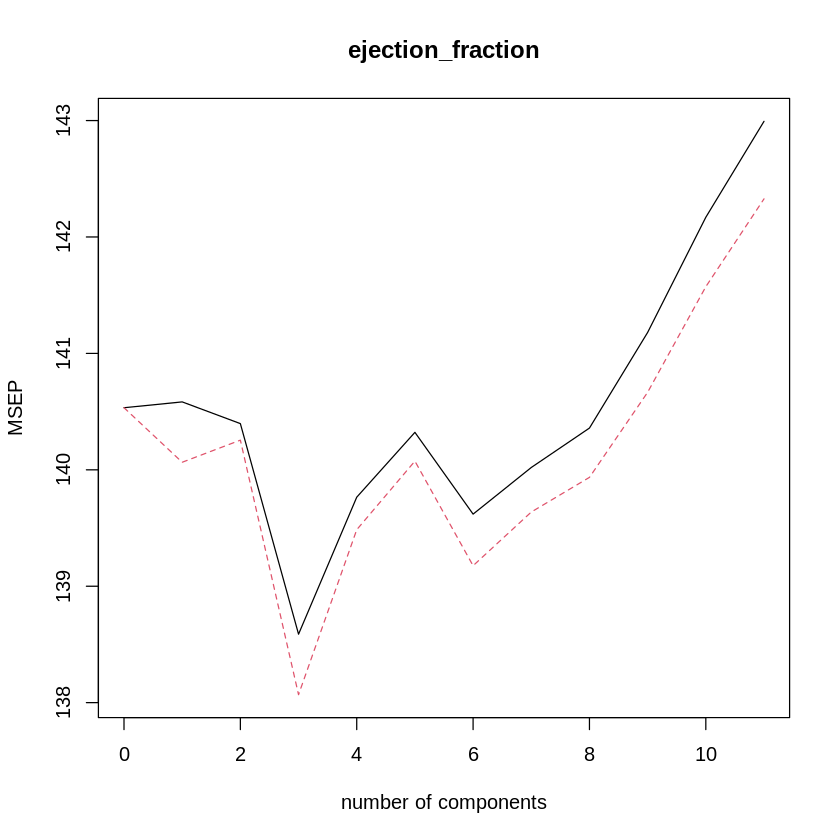

In [ ]:
validationplot(pcr.fit, val.type = "MSEP")

Once again, we see that the smallest cross-validation error occurs when $M=3$ components are used. This is consistent with the previous analysis which has typically concluded that using 2 or 3 predictors would provide the best model.

 The
`summary()` function also provides the *percentage of variance explained* in the predictors and in the response using different numbers of components.

This is the amount of information about the predictors or the
response that is captured using $M$ principal components. For example,
setting $M=1$ only captures $14.73\,\%$ of all the variance, or information,
in the predictors. In contrast, using $M=3$ increases the value to $39.89\,\%$. If we
were to use all $M=p=11$ components, this would increase to $100\,\%$.

Next, PCR is performed only on the training data and its test set performance is evaluated:

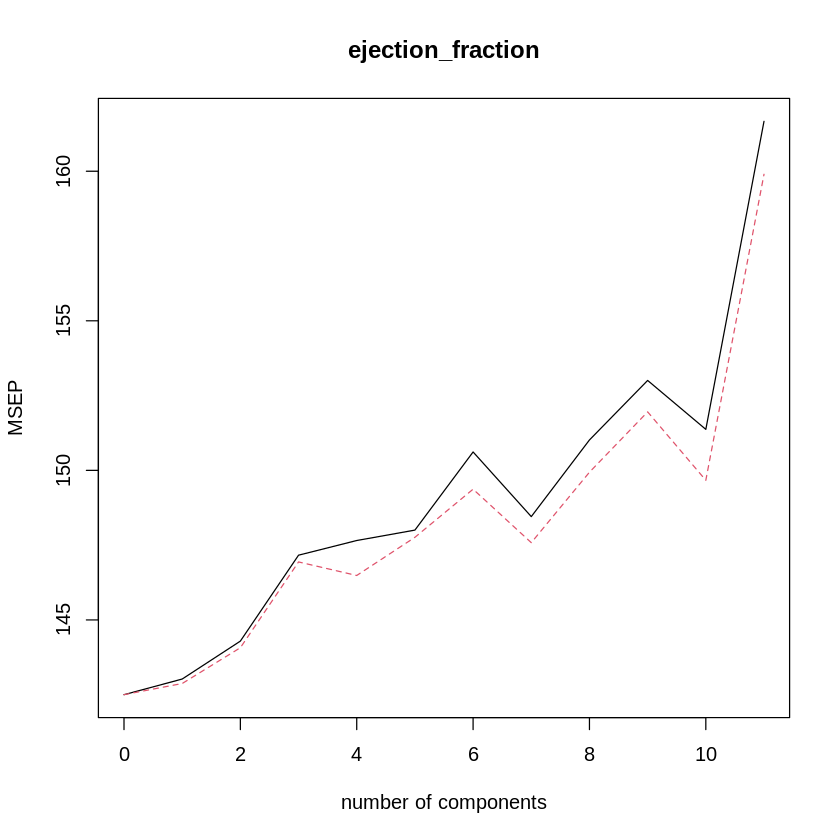

In [ ]:
set.seed(1)
pcr.fit <- pcr(ejection_fraction ~ . - DEATH_EVENT, data = HeartFailure, subset = train,
    scale = TRUE, validation = "CV")
validationplot(pcr.fit, val.type = "MSEP")

According to PCR, the lowest cross-validation error occurs when $M=1$ components are used.

We compute the test MSE as follows:

In [ ]:
pcr.pred <- predict(pcr.fit, x[test, ], ncomp = 1)
mean((pcr.pred - y.test)^2)

[1] 138.2482

PCR achieves a test MSE of approximately 138.25, which is comparable to ridge regression but slightly worse than lasso. The optimal model uses only one principal component, indicating that most of the predictive information is captured by a single linear combination of the predictors. However, as a result of the way PCR is implemented, the final model is more difficult to interpret because it does not perform any kind of variable selection or even directly produce coefficient estimates.

PCR is fitted on the full data set, using $M=1$, the number of components identified by cross-validation:

In [ ]:
pcr.fit <- pcr(y ~ x, scale = TRUE, ncomp = 1)
summary(pcr.fit)

Data: 	X dimension: 299 11 
	Y dimension: 299 1
Fit method: svdpc
Number of components considered: 1
TRAINING: % variance explained
   1 comps
X   14.731
y    1.465


The first principal component explains only 14.7% of the variance in the predictors and just 1.5% of the variance in the response, indicating that the dominant variation in the predictors is not strongly related to the outcome.

### Partial Least Squares

Furthermore, when PLS regression was applied, cross-validation indicated that the lowest prediction error occurs with one component, with performance remaining relatively flat as additional components are added.

Data: 	X dimension: 149 11 
	Y dimension: 149 1
Fit method: kernelpls
Number of components considered: 11

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           11.94    12.53    12.67    12.71    12.71    12.71    12.71
adjCV        11.94    12.47    12.60    12.64    12.65    12.64    12.64
       7 comps  8 comps  9 comps  10 comps  11 comps
CV       12.71    12.71    12.71     12.71     12.71
adjCV    12.65    12.65    12.65     12.65     12.65

TRAINING: % variance explained
                   1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
X                   10.590   21.822   30.578   42.462   52.271   58.909
ejection_fraction    6.364    7.085    7.171    7.175    7.176    7.176
                   7 comps  8 comps  9 comps  10 comps  11 comps
X                   65.745   75.895   82.724    90.506   100.000
ejection_fraction    7.176    7.176    7.176     7.176     7.176
(150 observa

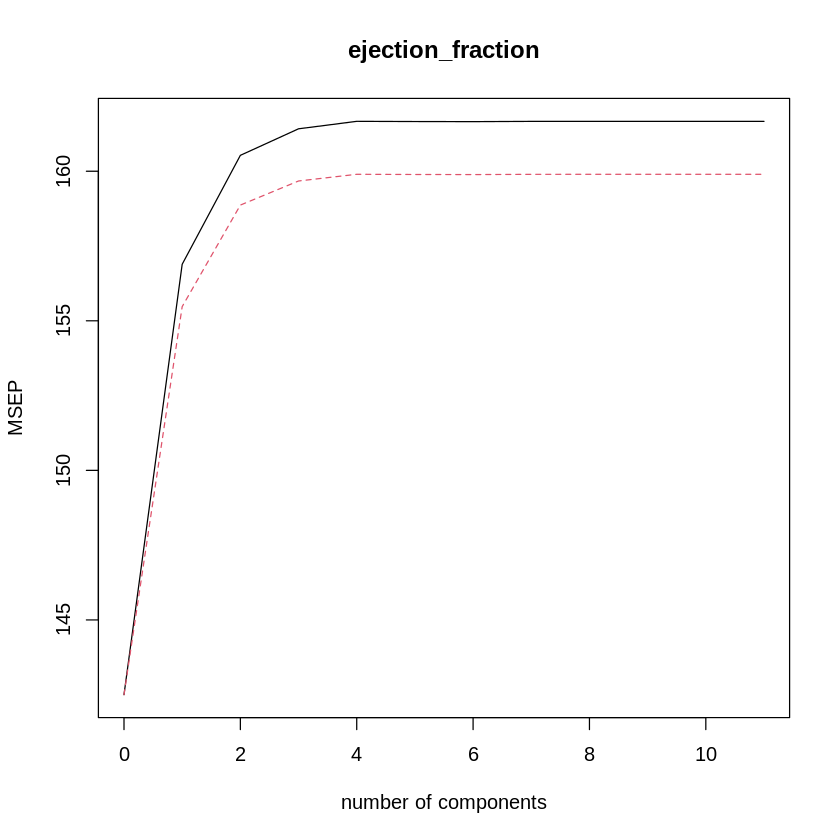

In [ ]:
set.seed(1)
pls.fit <- plsr(ejection_fraction ~ . -DEATH_EVENT, data = HeartFailure, subset = train, scale = TRUE, validation = "CV")
summary(pls.fit)
validationplot(pls.fit, val.type = "MSEP")

The lowest cross-validation error occurs when only $M=1$ partial least squares directions are used.

Next, the corresponding test set MSE is evaluated:

In [ ]:
pls.pred <- predict(pls.fit, x[test, ], ncomp = 1)
mean((pls.pred - y.test)^2)

[1] 136.7317

Once again, the test MSE is comparable to the test MSE obtained using ridge regression, the lasso, and PCR.

Finally, PLS is performed using the full data set, using $M=1$, the number of components identified by cross-validation:

In [ ]:
pls.fit <- plsr(ejection_fraction ~ . -DEATH_EVENT, data = HeartFailure, scale = TRUE,
    ncomp = 1)
summary(pls.fit)

Data: 	X dimension: 299 11 
	Y dimension: 299 1
Fit method: kernelpls
Number of components considered: 8
TRAINING: % variance explained
                   1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
X                   12.004   22.660   31.500   38.542   49.100   59.460
ejection_fraction    5.828    6.303    6.342    6.346    6.346    6.346
                   7 comps  8 comps
X                   67.026   75.038
ejection_fraction    6.346    6.346


The first PLS component explains 12.0% of the variance in the predictors and 5.8% of the variance in the response. Notably, increasing the number of components to eight raises the explained variance in the predictors to approximately 75%, but results in negligible improvement in the variance explained in the response. This indicates that additional components primarily capture variation in the predictors that is not relevant for prediction.



# 4. Results

##Previous Relevant Analysis

Regression analyses indicate that age, serum sodium, and sex are significantly associated with serum creatinine or ejection fraction. These two variables are recognized in prior research as critical indicators of heart failure patient survival.

Four classification techniques were evaluated using a held-out test set of 99 patients. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only ejection fraction and serum creatinine, test accuracy improved to approximately 85.9%.

##Current Analysis

In [ ]:
knitr::kable(results, caption = "Model Comparison Results")



Table: Model Comparison Results

|Method            | Optimal_Model_Size| CV_MSE| Test_MSE|Key_Features            |
|:-----------------|------------------:|------:|--------:|:-----------------------|
|Linear Regression |                 NA|     NA|   144.53|None (baseline)         |
|Best Subset       |                  2|     NA|       NA|sex, serum_sodium       |
|Forward Stepwise  |                  3|     NA|       NA|age, sex, serum_sodium  |
|Backward Stepwise |                  3|     NA|       NA|age, sex, serum_sodium  |
|Validation Set    |                  3|     NA|       NA|age, sex, serum_sodium  |
|Cross-Validation  |                  2| 134.53|       NA|sex, serum_sodium       |
|Ridge Regression  |                 NA|     NA|   136.83|All predictors (shrunk) |
|Lasso             |                  2|     NA|   137.18|sex, serum_sodium       |
|PCR               |                  1|     NA|   138.25|1 component             |
|PLS               |                  1| 

Best subset selection showed that small models performed best. While adjusted $R^2$ selected a three-variable model (age, sex, and serum sodium), both $C_p$ and BIC selected a simpler two-variable model including sex and serum sodium. Forward and backward stepwise selection produced very similar results, consistently identifying serum sodium, sex, and age as the most important predictors.

On the other hand, using the validation-set approach, the optimal model included anaemia, creatinine phosphokinase, and serum sodium for the training set.  However, the full dataset identified sex, age, and serum sodium as the three predictors. Additionally, when cross-validation was applied, the best model included only two predictors and achieved a cross-validated MSE of approximately 134.53.

For ridge regression, cross-validation selected a large value of $\lambda$ = 2077, with a cross-validated MSE of about 138.5. Whereas, the baseline model achieved a test MSE of 138.61.

For the lasso, cross-validation selected a model with two predictors, serum sodium and sex. The model achieved a test MSE of approximately 137.18. According to PCR, the lowest cross-validation error occurs when $M=1$ components are used. The first principal component explains only 14.7% of the variance in the predictors and just 1.5% of the variance in the response.

For PLS, cross-validation selected one component as optimal, with a cross-validated RMSE of approximately 12.53 (MSE ≈ 157.0), and the model achieved a test MSE of approximately 136.73.

#5. Discussion

##### ***Best Subset Selection***

The best subset selection results identify the optimal combination of predictors for each model size, with variables such as serum sodium, age, and sex consistently appearing in top-performing models. While adjusted R² is maximized at three variables, both Cp and BIC identify the optimal model at two variables.


#####***Forward  and Backward Stepwise Selection***

There is clear consistency as the weakest predictors remain: ` high blood pressure`, `smoking`, and`anaemia` and with the strongest predictors remaining as:`serum sodium`,`sex`, and `age`. Furthermore, the Cp plots for forward and backward selection are nearly identical.

#####***Validation-Set Approach and Cross-Validation***

Since model selection is based on minimizing test MSE, the optimal model identified using the validation set included a different set of predictors compared to the full dataset analysis. Specifically, anaemia and creatinine phosphokinase replaced age and sex, while serum sodium remained selected. Notably, anaemia was previously identified as a weaker predictor. While using the training set demonstrated that a three-variable model is best, the best clinical factors on the full dataset were once again `sex`, `age`, and `serum sodium`. When cross- validation was performed the model with the lowest error had 2 variables, and a cross-validated MSE of approximately 134.53.


##### ***Ridge Regression and the Lasso***
Cross-validation selects a large value of λ (approximately 2077) as minimizing the validation error, the test MSE is 138.55. This performance is slightly better than a baseline model that predicts the mean of the training response, which achieved a test MSE of 138.61.


#####***Principal Components Regression and Partial Lease Squares***
Although initial results on the full data suggested that 3 components may be optimal, cross-validation on the training data shows that only 1 component is needed, indicating that additional components do not improve predictive performance and may lead to overfitting. The first principal component explains only 14.7% of the variance in the predictors and just 1.5% of the variance in the response, indicating that the dominant variation in the predictors is not strongly related to the outcome. Furthermore, the lowest cross-validation error occurs when only $M=1$ partial least squares directions are used (Test MSE = 136.73).The first PLS component explains 12.0% of the variance in the predictors and 5.8% of the variance in the response.




# 6. Conclusion

The results of this study show that simpler models perform similarly, and in some cases better, than more complex ones when predicting ejection fraction in heart failure patients. Across multiple methods, variables like serum sodium, sex, and age consistently appeared as the most important predictors, while others such as smoking, anaemia, and high blood pressure contributed little to improving model performance.

Cross-validation and best subset criteria favor a simpler two-variable model (sex and serum sodium), while subset and stepwise approaches support a slightly larger three-variable model that additionally includes age.PCR and PLS further suggest that the data can be summarized into a single component, meaning only a small amount of information is needed for effective prediction.

 Overall, the findings suggest that increasing model complexity does not necessarily lead to better predictions. Instead, a smaller model with a few key variables provides a more efficient and interpretable solution without sacrificing accuracy, supporting the idea that focusing on the most relevant clinical factors is more valuable than including all available data.

# 7. Appendix


## Tables

In [ ]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)

In [ ]:
results <- data.frame(
  Method = c("Linear Regression", "Best Subset", "Forward Stepwise", "Backward Stepwise",
             "Validation Set", "Cross-Validation",
             "Ridge Regression", "Lasso",
             "PCR", "PLS"),

  Optimal_Model_Size = c(NA, 2 , 3, 3, 3, 2, NA, 2, 1, 1),

  CV_MSE = c(NA, NA, NA, NA, NA, 134.53, NA, NA, NA, 157.0),

  Test_MSE = c(144.53, NA, NA, NA, NA, NA, 138.5, 137.18, 138.25, 136.73),

  Key_Features = c(
    "None (baseline)",
    "sex, serum_sodium, age(if 3)",
    "age, sex, serum_sodium",
    "age, sex, serum_sodium",
    "age, sex, serum_sodium",
    "sex, serum_sodium",
    "All predictors (shrunk)",
    "sex, serum_sodium",
    "1 component",
    "1 component"
  )
)

knitr::kable(results, caption = "Model Comparison Using CV and Test MSE")



Table: Model Comparison Using CV and Test MSE

|Method            | Optimal_Model_Size| CV_MSE| Test_MSE|Key_Features                 |
|:-----------------|------------------:|------:|--------:|:----------------------------|
|Linear Regression |                 NA|     NA|   144.53|None (baseline)              |
|Best Subset       |                  2|     NA|       NA|sex, serum_sodium, age(if 3) |
|Forward Stepwise  |                  3|     NA|       NA|age, sex, serum_sodium       |
|Backward Stepwise |                  3|     NA|       NA|age, sex, serum_sodium       |
|Validation Set    |                  3|     NA|       NA|age, sex, serum_sodium       |
|Cross-Validation  |                  2| 134.53|       NA|sex, serum_sodium            |
|Ridge Regression  |                 NA|     NA|   138.50|All predictors (shrunk)      |
|Lasso             |                  2|     NA|   137.18|sex, serum_sodium            |
|PCR               |                  1|     NA|   138.25|1 c